In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ESCAPE pressure output comparisons

[nCX] 125729.03589: successful 20, failed 0 (-), pending 0 (-)
  pressure formula: 2*ne*Te
  plotting alpha_crit = 0.01 (10 of 20 runs)
  experimental p_ped: mean 6.0 kPa, range [5.0, 6.6] kPa


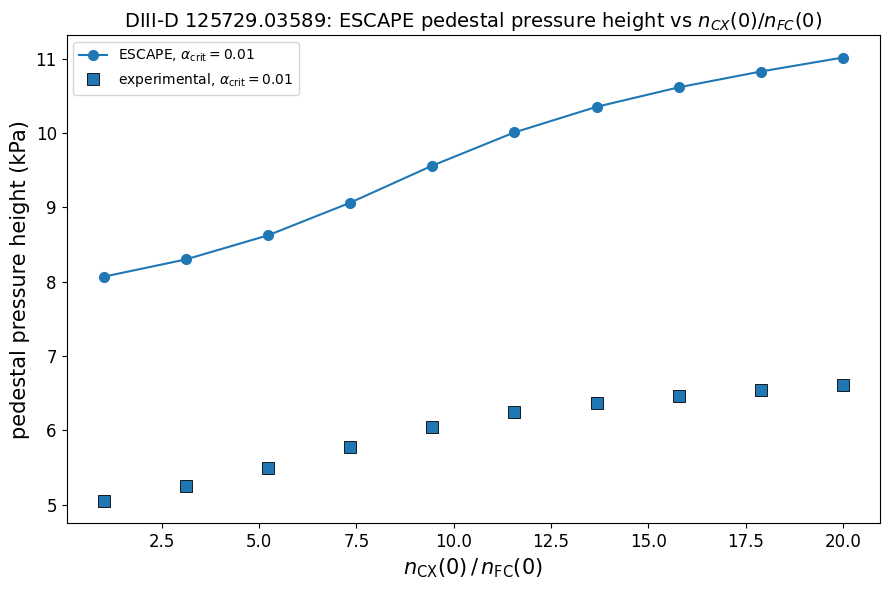

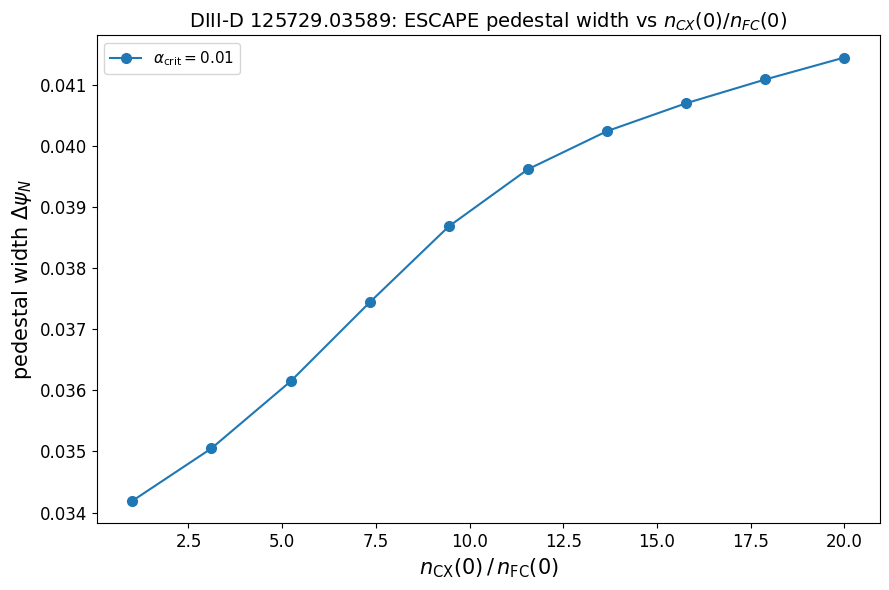

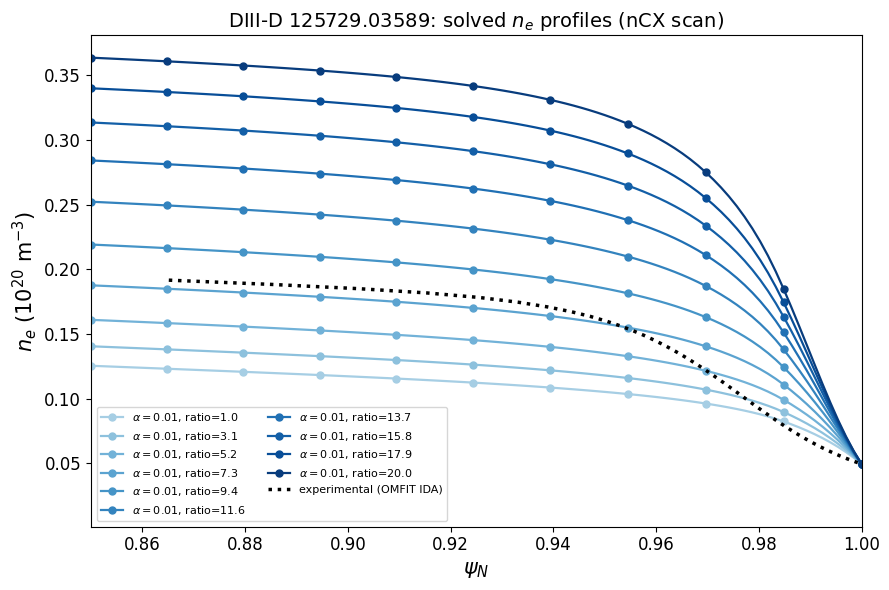

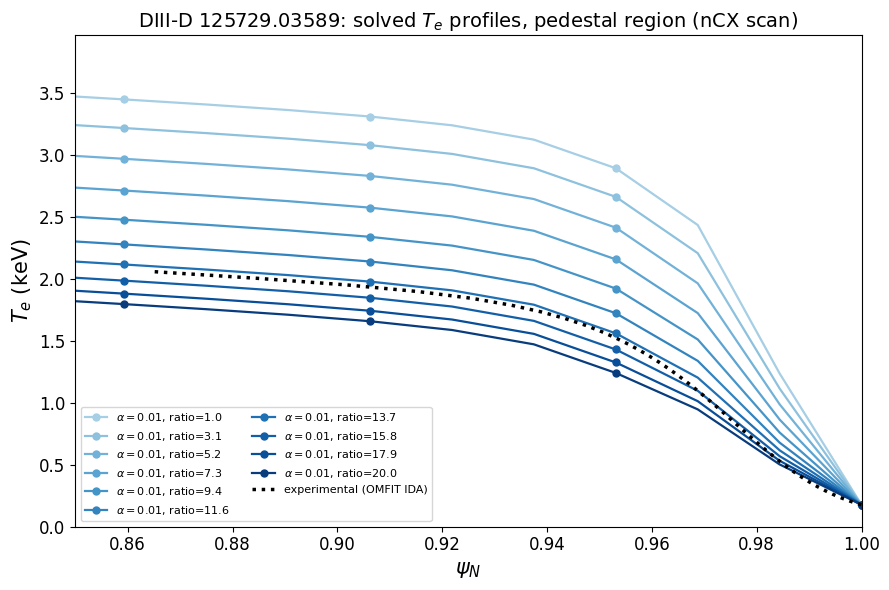

[nFC] 125729.03589: successful 14, failed 6 (i8, i9, i16, i17, i18, i19), pending 0 (-)
  pressure formula: 2*ne*Te
  plotting alpha_crit = 0.01 (8 of 14 runs)
  experimental p_ped: mean 6.5 kPa, range [5.0, 9.6] kPa


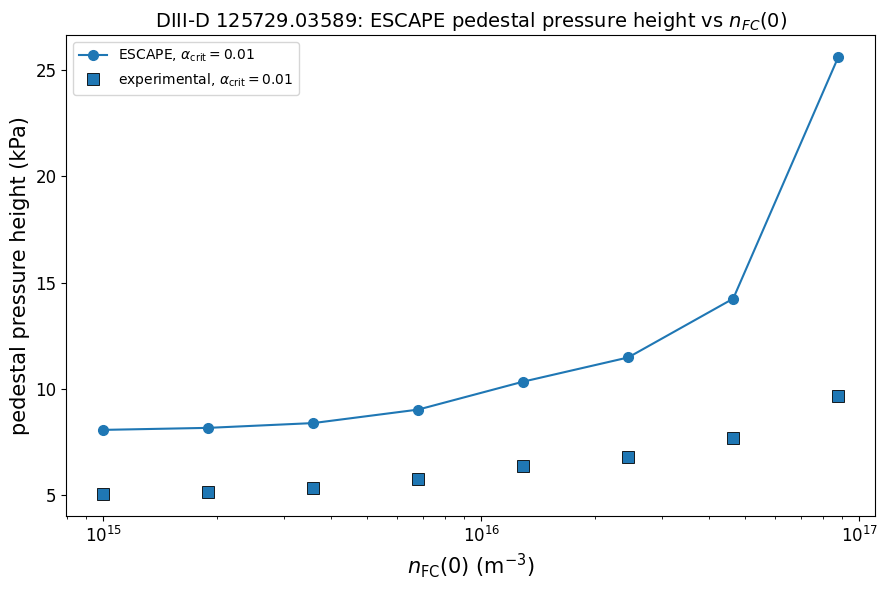

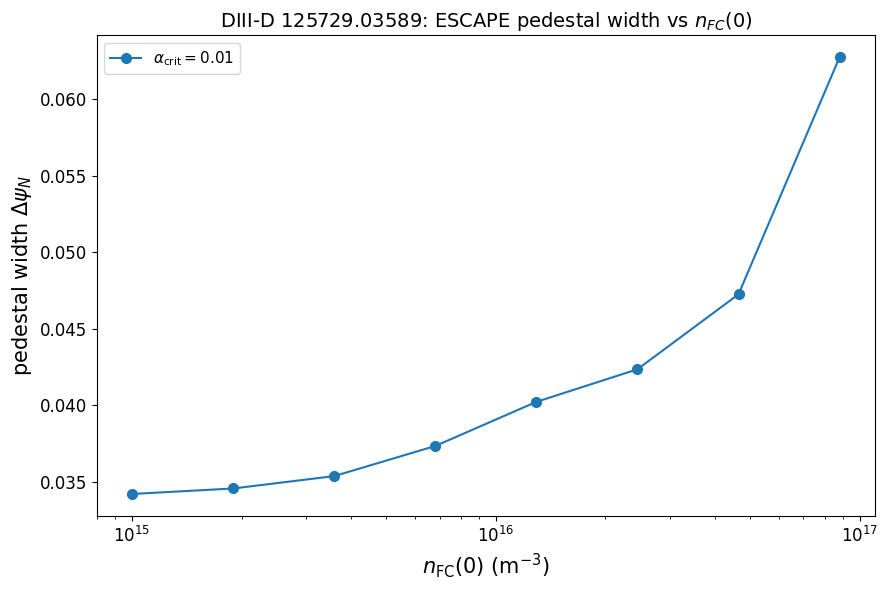

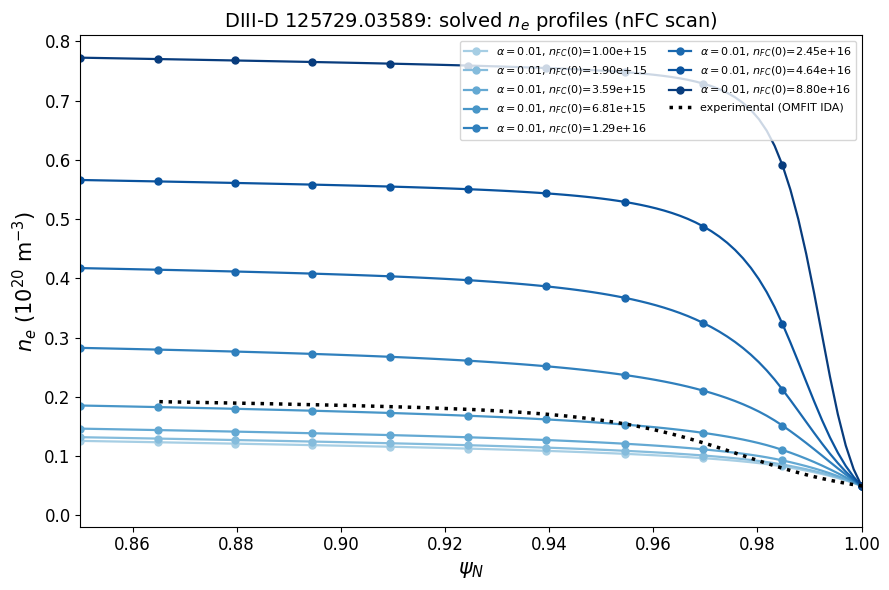

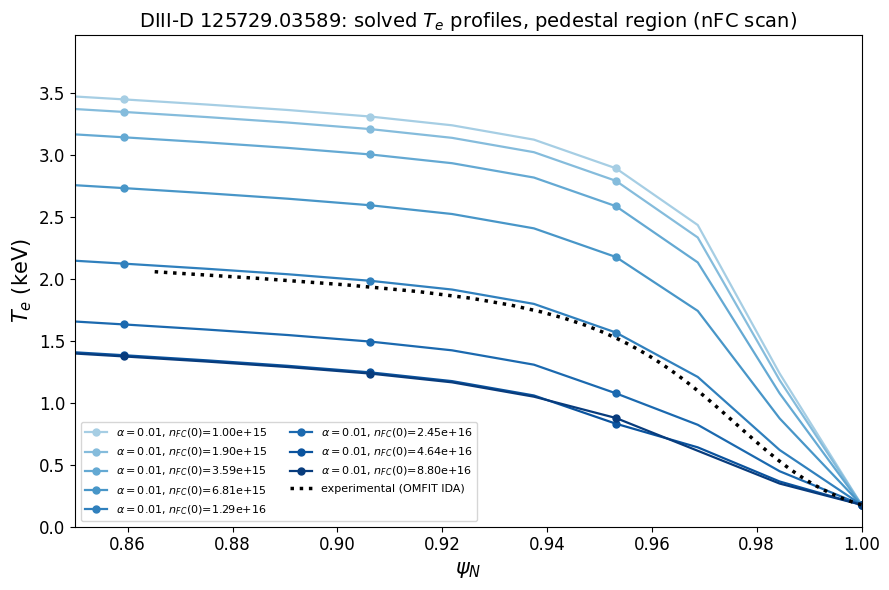

In [2]:
# --- DIII-D nCX/nFC scans for ONE equilibrium: ESCAPE pedestal height / width, and the solved profiles ---
# Reads DIIIDSnyder_freeparam_loop_{nCX,nFC}/{EQUIL}/i{i}/ (out_dict.npy on success,
# failed.npy on failure; a run dir with neither is still in flight and is skipped).
# The "experimental" pedestal pressure is the one scan_SCfp_ESCAPE.py already stored:
# the input (OMFIT IDA) profile pressure p = 2*ne*Te evaluated at psi_N = 1 - ped_wid,
# using each run's OWN ped_wid. The experimental ne/Te curves are those same inputs.

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------ user input
EQUIL = '125729.03589'      # equilibrium tag = <shot>.<time>, i.e. the sub-directory name
PSI_LO = 0.85               # pedestal window for the profile plots
# Which alpha_crit families to draw: None plots every one in the scan, or give a
# single value (0.01) or a list ([0.01, 10]) to plot only those and cut the clutter.
ALPHA_CRITS = (0.01)
# -----------------------------------------------------------------------------

SCAN_DIRS = {
    'nCX': Path('DIIIDSnyder_freeparam_loop_nCX'),
    'nFC': Path('DIIIDSnyder_freeparam_loop_nFC'),
}
# per-scan: which free parameter is on the x axis, and how to label it
SCAN_SPEC = {
    'nCX': dict(key='ncx_x0_ratio',
                axis_label=r'$n_{\mathrm{CX}}(0)\,/\,n_{\mathrm{FC}}(0)$',
                title_label=r'$n_{CX}(0)/n_{FC}(0)$',
                logx=False,
                fmt=lambda v: f'ratio={v:.1f}'),
    'nFC': dict(key='nFC_x0',
                axis_label=r'$n_{\mathrm{FC}}(0)$ (m$^{-3}$)',
                title_label=r'$n_{FC}(0)$',
                logx=True,
                fmt=lambda v: rf'$n_{{FC}}(0)$={v:.2e}'),
}

# Blue for alpha_crit = 0.01, green for alpha_crit = 10.
ALPHA_COLORS = {0.01: 'tab:blue', 10.0: 'tab:green'}
ALPHA_CMAPS = {0.01: plt.cm.Blues, 10.0: plt.cm.Greens}
# distinct marker per alpha_crit, so the two families stay separable in greyscale
ALPHA_MARKERS = {0.01: 'o', 10.0: '^'}


def _lookup(table, a, default):
    for key, val in table.items():
        if np.isclose(a, key):
            return val
    return default


def alpha_color(a):
    return _lookup(ALPHA_COLORS, a, 'tab:gray')


def alpha_cmap(a):
    return _lookup(ALPHA_CMAPS, a, plt.cm.Greys)


def alpha_marker(a):
    return _lookup(ALPHA_MARKERS, a, 'x')


def select_alphas(alpha_vals, selection):
    """The alpha_crit values to plot, given the ones a scan actually contains.

    `selection` is None (keep everything), a single value, or a list of values;
    anything requested that the scan does not hold is reported and dropped.
    """
    if selection is None:
        return list(alpha_vals)
    wanted = np.atleast_1d(np.asarray(selection, dtype=float))
    missing = [f'{w:g}' for w in wanted if not np.isclose(w, alpha_vals).any()]
    if missing:
        print(f'  requested alpha_crit not in this scan: {", ".join(missing)} '
              f'(available: {", ".join(f"{a:g}" for a in alpha_vals)})')
    return [a for a in alpha_vals if np.isclose(a, wanted).any()]


def load_runs(scan_dir, equil, param_key):
    """All finished runs for one equilibrium of one scan, sorted by param_key.

    Returns (runs, failed, pending). Pedestal height is converted MPa -> kPa and
    the stored experimental pressure Pa -> kPa, matching the SPARC notebook.
    """
    equil_dir = Path(scan_dir) / equil
    if not equil_dir.is_dir():
        raise FileNotFoundError(f'no such equilibrium directory: {equil_dir}')

    runs, failed, pending = [], [], []
    for run_dir in sorted(equil_dir.glob('i*'), key=lambda p: int(p.name[1:])):
        out_fp = run_dir / 'out_dict.npy'
        if not out_fp.exists():
            (failed if (run_dir / 'failed.npy').exists() else pending).append(run_dir.name)
            continue
        d = np.load(out_fp, allow_pickle=True).item()
        runs.append({
            'alpha_crit': float(d['free_params']['alpha_crit']),
            'param':      float(d['free_params'][param_key]),
            'ped_h':      float(d['ESCAPE_ped_h']) * 1e3,        # MPa -> kPa
            'ped_wid':    float(d['ESCAPE_ped_wid']),
            'p_exp':      float(d['experimental_ped_h']) / 1e3,  # Pa  -> kPa
            'sol':        d['profiles_solved'],
            'profiles':   d['profiles'],
            'p_mode':     d['p_mode'],
        })
    runs.sort(key=lambda r: (r['alpha_crit'], r['param']))
    return runs, failed, pending


for scan_name, scan_dir in SCAN_DIRS.items():
    spec = SCAN_SPEC[scan_name]
    runs, failed, pending = load_runs(scan_dir, EQUIL, spec['key'])
    if not runs:
        print(f'[{scan_name}] {EQUIL}: no successful runs, skipping')
        continue

    print(f'[{scan_name}] {EQUIL}: successful {len(runs)}, '
          f'failed {len(failed)} ({", ".join(failed) or "-"}), '
          f'pending {len(pending)} ({", ".join(pending) or "-"})')
    print(f'  pressure formula: {runs[0]["p_mode"]}')

    alpha_vals = select_alphas(sorted({r['alpha_crit'] for r in runs}), ALPHA_CRITS)
    if not alpha_vals:
        print('  nothing left after the alpha_crit selection, skipping')
        continue
    groups = {a: [r for r in runs if np.isclose(r['alpha_crit'], a)] for a in alpha_vals}
    if ALPHA_CRITS is not None:
        n_sel = sum(len(g) for g in groups.values())
        print(f'  plotting alpha_crit = {", ".join(f"{a:g}" for a in alpha_vals)} '
              f'({n_sel} of {len(runs)} runs)')

    # The experimental value moves with ped_wid, so it is not a single number
    # across the scan; report its spread instead of drawing one reference line.
    p_exp_all = np.array([r['p_exp'] for g in groups.values() for r in g])
    print(f'  experimental p_ped: mean {p_exp_all.mean():.1f} kPa, '
          f'range [{p_exp_all.min():.1f}, {p_exp_all.max():.1f}] kPa')

    # --- 1. ESCAPE pedestal pressure height vs the scanned parameter -------------
    fig, ax = plt.subplots(figsize=(9, 6))
    for a in alpha_vals:
        g = groups[a]
        c = alpha_color(a)
        ax.plot([r['param'] for r in g], [r['ped_h'] for r in g],
                'o-', color=c, markersize=7,
                label=rf'ESCAPE, $\alpha_{{\mathrm{{crit}}}}={a:g}$')
        ax.plot([r['param'] for r in g], [r['p_exp'] for r in g],
                's', color=c, markersize=8, linestyle='none',
                markeredgecolor='black', markeredgewidth=0.6,
                label=rf'experimental, $\alpha_{{\mathrm{{crit}}}}={a:g}$')

    if spec['logx']:
        ax.set_xscale('log')
    ax.set_xlabel(spec['axis_label'], fontsize=15)
    ax.set_ylabel(r'pedestal pressure height (kPa)', fontsize=15)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=10, loc='best')
    ax.set_title(f'DIII-D {EQUIL}: ESCAPE pedestal pressure height vs '
                 f'{spec["title_label"]}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- 2. ESCAPE pedestal width vs the scanned parameter (no reference line) ---
    fig, ax = plt.subplots(figsize=(9, 6))
    for a in alpha_vals:
        g = groups[a]
        ax.plot([r['param'] for r in g], [r['ped_wid'] for r in g],
                'o-', color=alpha_color(a), markersize=7,
                label=rf'$\alpha_{{\mathrm{{crit}}}}={a:g}$')

    if spec['logx']:
        ax.set_xscale('log')
    ax.set_xlabel(spec['axis_label'], fontsize=15)
    ax.set_ylabel(r'pedestal width $\Delta\psi_N$', fontsize=15)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, loc='best')
    ax.set_title(f'DIII-D {EQUIL}: ESCAPE pedestal width vs '
                 f'{spec["title_label"]}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # experimental (input) profiles: identical for every run of this equilibrium
    exp_prof = runs[0]['profiles']
    psi_ne_exp = np.asarray(exp_prof['psi_N_ne'], dtype=float)
    ne_exp = np.asarray(exp_prof['ne'], dtype=float)
    psi_Te_exp = np.asarray(exp_prof['psi_N_Te'], dtype=float)
    te_exp = np.asarray(exp_prof['Te'], dtype=float)   # keV
    ped_ne = psi_ne_exp >= PSI_LO
    ped_Te = psi_Te_exp >= PSI_LO

    # --- 3. solved n_e profiles for every free-parameter combination -------------
    fig, ax = plt.subplots(figsize=(9, 6))
    for a in alpha_vals:
        g = groups[a]
        cm, mk = alpha_cmap(a), alpha_marker(a)
        for j, r in enumerate(g):
            shade = cm(0.35 + 0.6 * j / max(len(g) - 1, 1))
            sol = r['sol']
            ax.plot(sol['psi_N_ne'], np.asarray(sol['y']) / 1e20, '-',
                    color=shade, linewidth=1.6,
                    marker=mk, markersize=5, markevery=10,
                    label=rf'$\alpha={a:g}$, {spec["fmt"](r["param"])}')

    ax.plot(psi_ne_exp[ped_ne], ne_exp[ped_ne] / 1e20, 'k:',
            linewidth=2.5, zorder=10, label='experimental (OMFIT IDA)')

    ax.set_xlabel(r'$\psi_N$', fontsize=15)
    ax.set_ylabel(r'$n_e$ ($10^{20}$ m$^{-3}$)', fontsize=15)
    ax.set_xlim(PSI_LO, 1.0)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=8, loc='best', ncol=2)
    ax.set_title(f'DIII-D {EQUIL}: solved $n_e$ profiles ({scan_name} scan)', fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- 4. solved T_e profiles for every free-parameter combination -------------
    fig, ax = plt.subplots(figsize=(9, 6))
    te_ped_max = 0.0
    for a in alpha_vals:
        g = groups[a]
        cm, mk = alpha_cmap(a), alpha_marker(a)
        for j, r in enumerate(g):
            shade = cm(0.35 + 0.6 * j / max(len(g) - 1, 1))
            sol = r['sol']
            psi = np.asarray(sol['psi_N'])
            te_keV = np.asarray(sol['T_e']) / 1e3
            # T_e lives on the full-radius grid, so mark more often than n_e
            # to get a comparable marker density inside the pedestal window
            ax.plot(psi, te_keV, '-', color=shade, linewidth=1.6,
                    marker=mk, markersize=5, markevery=3,
                    label=rf'$\alpha={a:g}$, {spec["fmt"](r["param"])}')
            te_ped_max = max(te_ped_max, float(te_keV[psi >= PSI_LO].max()))

    ax.plot(psi_Te_exp[ped_Te], te_exp[ped_Te], 'k:', linewidth=2.5, zorder=10,
            label='experimental (OMFIT IDA)')
    te_ped_max = max(te_ped_max, float(te_exp[ped_Te].max()))

    ax.set_xlabel(r'$\psi_N$', fontsize=15)
    ax.set_ylabel(r'$T_e$ (keV)', fontsize=15)
    ax.set_xlim(PSI_LO, 1.0)
    # scale y to the pedestal window, not the (much hotter) core
    ax.set_ylim(0, 1.15 * te_ped_max)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=8, loc='best', ncol=2)
    ax.set_title(f'DIII-D {EQUIL}: solved $T_e$ profiles, pedestal region '
                 f'({scan_name} scan)', fontsize=14)
    plt.tight_layout()
    plt.show()

[nCX]
  125729.03589: successful 10, failed 0, pending 0
  125730.02445: successful 10, failed 0, pending 0
  125731.02893: successful 10, failed 0, pending 0
  125732.03508: successful 10, failed 0, pending 0
  125761.03760: successful 10, failed 0, pending 0
  125787.03894: successful 10, failed 0, pending 0
  128398.04295: successful 10, failed 0, pending 0
  128413.04088: successful 10, failed 0, pending 0
  128572.03809: successful 10, failed 0, pending 0
  128578.03658: successful 10, failed 0, pending 0
  131499.04439: successful 10, failed 0, pending 0
  131711.03067: successful 10, failed 0, pending 0
  131712.04009: successful 10, failed 0, pending 0
  131922.04192: successful 10, failed 0, pending 0


  131923.03394: successful 10, failed 0, pending 0
  131996.03020: successful 10, failed 0, pending 0
  131997.03020: successful 10, failed 0, pending 0
  131999.03020: successful 10, failed 0, pending 0
  132000.03020: successful 10, failed 0, pending 0
  132002.03020: successful 10, failed 0, pending 0
  132003.03021: successful 10, failed 0, pending 0
  132006.03004: successful 10, failed 0, pending 0
  132007.01288: successful 10, failed 0, pending 0
  132009.03020: successful 10, failed 0, pending 0
  132010.03020: successful 10, failed 0, pending 0
  132011.03020: successful 10, failed 0, pending 0
  132013.02771: successful 10, failed 0, pending 0
  132014.02721: successful 10, failed 0, pending 0
  132016.03020: successful 10, failed 0, pending 0
  132018.02020: successful 10, failed 0, pending 0
  132019.01620: successful 10, failed 0, pending 0
  132020.01965: successful 10, failed 0, pending 0
  133103.03535: successful 10, failed 0, pending 0
  133137.03209: successful 10, 

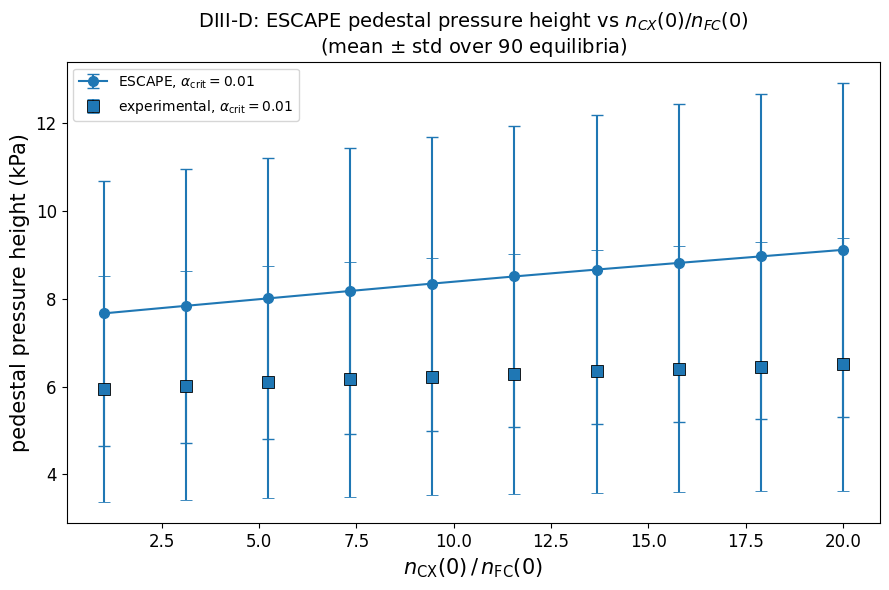

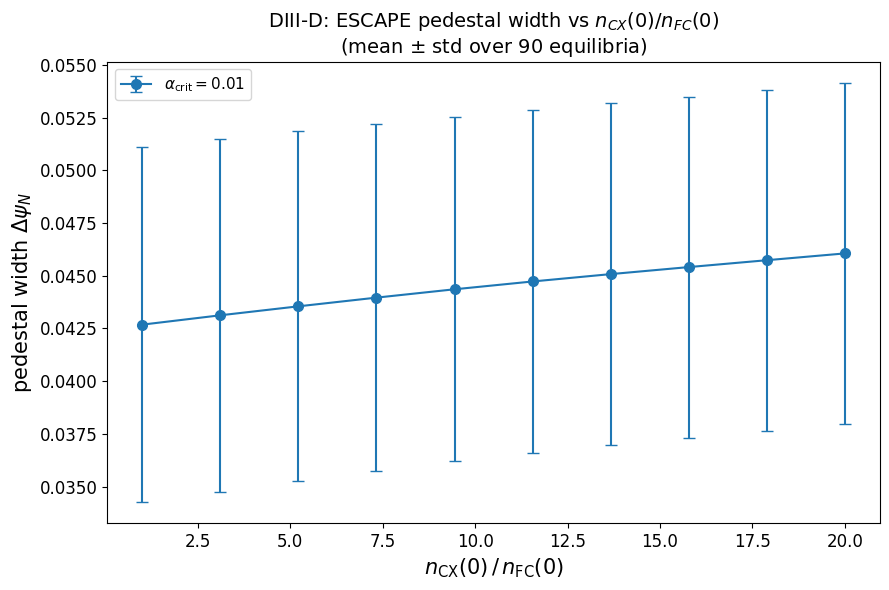

[nFC]
  125729.03589: successful 8, failed 6, pending 0
  125730.02445: successful 8, failed 6, pending 0
  125731.02893: successful 8, failed 6, pending 0
  125732.03508: successful 9, failed 5, pending 0
  125761.03760: successful 9, failed 5, pending 0
  125787.03894: successful 10, failed 4, pending 0
  128398.04295: successful 10, failed 0, pending 0
  128413.04088: successful 10, failed 1, pending 0
  128572.03809: successful 10, failed 0, pending 0
  128578.03658: successful 10, failed 0, pending 0
  131499.04439: successful 10, failed 1, pending 0
  131711.03067: successful 10, failed 2, pending 0
  131712.04009: successful 10, failed 2, pending 0
  131922.04192: successful 10, failed 3, pending 0
  131923.03394: successful 10, failed 3, pending 0
  131996.03020: successful 10, failed 0, pending 0
  131997.03020: successful 10, failed 0, pending 0
  131999.03020: successful 10, failed 0, pending 0
  132000.03020: successful 10, failed 1, pending 0
  132002.03020: successful 10,

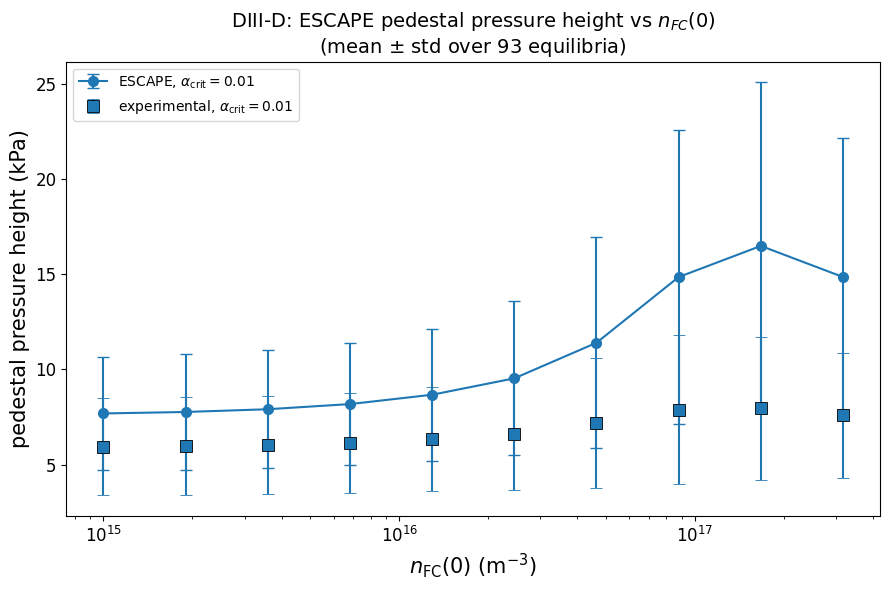

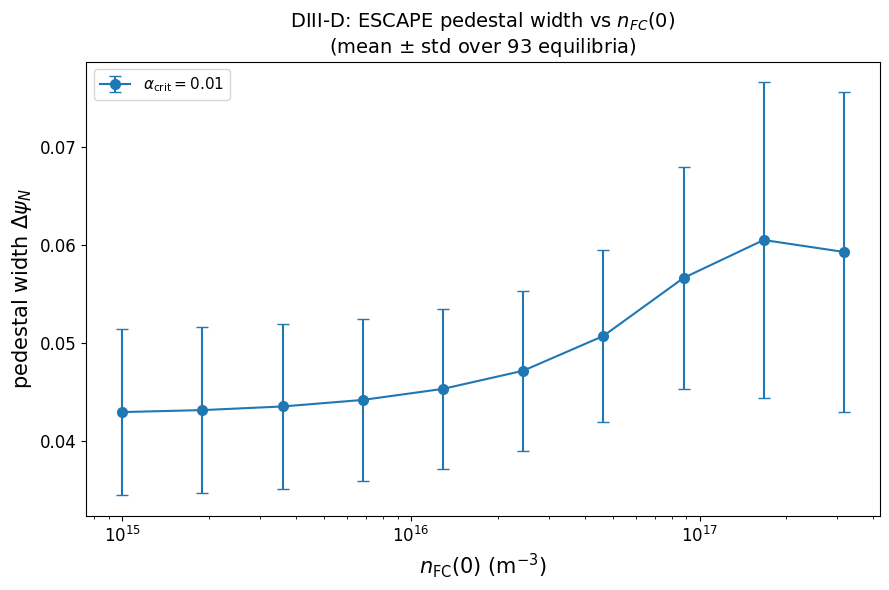

In [3]:
# --- Same two ESCAPE scalar plots, averaged over the DIII-D equilibria ---
# Every equilibrium directory found in the scan output directory is used. For each
# (alpha_crit, scanned-parameter) point the marker is the mean over the equilibria
# whose run converged and the error bar is their standard deviation; a run that
# failed (or has not finished) simply drops out of that point's average.
# Needs the loaders/colour helpers defined in the single-equilibrium cell above,
# and honours the same ALPHA_CRITS selection set there.

def average_over_equilibria(scan_dir, param_key):
    """Mean and std over equilibria of ped_h / ped_wid / p_exp, per (alpha, param).

    Returns (points, equils_used); each point is a dict with the mean/std of the
    three quantities and `n`, the number of equilibria that contributed.
    """
    scan_dir = Path(scan_dir)
    keep_alphas = None   # resolved from ALPHA_CRITS on the first equilibrium read
    per_point = {}       # (alpha_crit, param) -> {quantity: [values over equilibria]}
    equils_used = []
    for equil_dir in sorted(p for p in scan_dir.iterdir() if p.is_dir()):
        equil = equil_dir.name
        runs, failed, pending = load_runs(scan_dir, equil, param_key)
        # Keep only the alpha_crit families ALPHA_CRITS asks for. The available
        # values are known only once a run has been read, so resolve them on the
        # first equilibrium that has any and reuse that selection for the rest.
        if keep_alphas is None and runs:
            keep_alphas = select_alphas(
                sorted({r['alpha_crit'] for r in runs}), ALPHA_CRITS)
        if keep_alphas is not None:
            runs = [r for r in runs
                    if np.isclose(r['alpha_crit'], keep_alphas).any()]
        if not runs:
            print(f'  {equil}: no successful runs at the selected alpha_crit, skipped')
            continue
        equils_used.append(equil)
        print(f'  {equil}: successful {len(runs)}, failed {len(failed)}, pending {len(pending)}')
        for r in runs:
            key = (r['alpha_crit'], r['param'])
            slot = per_point.setdefault(key, {'ped_h': [], 'ped_wid': [], 'p_exp': []})
            for q in slot:
                slot[q].append(r[q])

    points = []
    for (a, param), vals in sorted(per_point.items()):
        pt = {'alpha_crit': a, 'param': param, 'n': len(vals['ped_h'])}
        for q, v in vals.items():
            v = np.asarray(v, dtype=float)
            pt[q] = float(v.mean())
            pt[q + '_std'] = float(v.std())   # population std over the equilibria
        points.append(pt)
    return points, equils_used


for scan_name, scan_dir in SCAN_DIRS.items():
    spec = SCAN_SPEC[scan_name]
    print(f'[{scan_name}]')
    points, equils_used = average_over_equilibria(scan_dir, spec['key'])
    if not points:
        print('  no successful runs in this scan, skipping')
        continue
    # Points where a run failed for some equilibria average over fewer of them.
    n_per_point = sorted({p['n'] for p in points})
    print(f'  {len(points)} scan points from {len(equils_used)} equilibria '
          f'({", ".join(equils_used)}); equilibria per point: {n_per_point}')

    alpha_vals = sorted({p['alpha_crit'] for p in points})
    groups = {a: sorted([p for p in points if np.isclose(p['alpha_crit'], a)],
                        key=lambda p: p['param'])
              for a in alpha_vals}
    equil_note = f'mean $\\pm$ std over {len(equils_used)} equilibria'

    # --- 1. ESCAPE pedestal pressure height vs the scanned parameter -------------
    fig, ax = plt.subplots(figsize=(9, 6))
    for a in alpha_vals:
        g = groups[a]
        c = alpha_color(a)
        x = [p['param'] for p in g]
        ax.errorbar(x, [p['ped_h'] for p in g], yerr=[p['ped_h_std'] for p in g],
                    fmt='o-', color=c, markersize=7,
                    ecolor=c, elinewidth=1.5, capsize=4,
                    label=rf'ESCAPE, $\alpha_{{\mathrm{{crit}}}}={a:g}$')
        ax.errorbar(x, [p['p_exp'] for p in g], yerr=[p['p_exp_std'] for p in g],
                    fmt='s', color=c, markersize=8, linestyle='none',
                    markeredgecolor='black', markeredgewidth=0.6,
                    ecolor=c, elinewidth=1.5, capsize=4,
                    label=rf'experimental, $\alpha_{{\mathrm{{crit}}}}={a:g}$')

    if spec['logx']:
        ax.set_xscale('log')
    ax.set_xlabel(spec['axis_label'], fontsize=15)
    ax.set_ylabel(r'pedestal pressure height (kPa)', fontsize=15)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=10, loc='best')
    ax.set_title(f'DIII-D: ESCAPE pedestal pressure height vs {spec["title_label"]}\n'
                 f'({equil_note})', fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- 2. ESCAPE pedestal width vs the scanned parameter (no reference line) ---
    fig, ax = plt.subplots(figsize=(9, 6))
    for a in alpha_vals:
        g = groups[a]
        ax.errorbar([p['param'] for p in g], [p['ped_wid'] for p in g],
                    yerr=[p['ped_wid_std'] for p in g],
                    fmt='o-', color=alpha_color(a), markersize=7,
                    ecolor=alpha_color(a), elinewidth=1.5, capsize=4,
                    label=rf'$\alpha_{{\mathrm{{crit}}}}={a:g}$')

    if spec['logx']:
        ax.set_xscale('log')
    ax.set_xlabel(spec['axis_label'], fontsize=15)
    ax.set_ylabel(r'pedestal width $\Delta\psi_N$', fontsize=15)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, loc='best')
    ax.set_title(f'DIII-D: ESCAPE pedestal width vs {spec["title_label"]}\n'
                 f'({equil_note})', fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot ne_outer scan results


[nCXneouter] 125729.03589: successful 48, failed 0 (-), pending 0 (-)
  plotting alpha_crit = 0.01
  largest converged n_CX(0)/n_FC(0) ratio per n_e^outer:
    n_e^outer =  solver default: max ratio =     20 (8 runs)
    n_e^outer =      1e+20 m^-3: max ratio =     20 (8 runs)
    n_e^outer =      2e+20 m^-3: max ratio =     20 (8 runs)
[nCXneouter] 125730.02445: successful 45, failed 0 (-), pending 1 (neouter2_fp13)
  plotting alpha_crit = 0.01
  largest converged n_CX(0)/n_FC(0) ratio per n_e^outer:
    n_e^outer =  solver default: max ratio =     20 (8 runs)
    n_e^outer =      1e+20 m^-3: max ratio =     20 (8 runs)
    n_e^outer =      2e+20 m^-3: max ratio =     20 (8 runs)


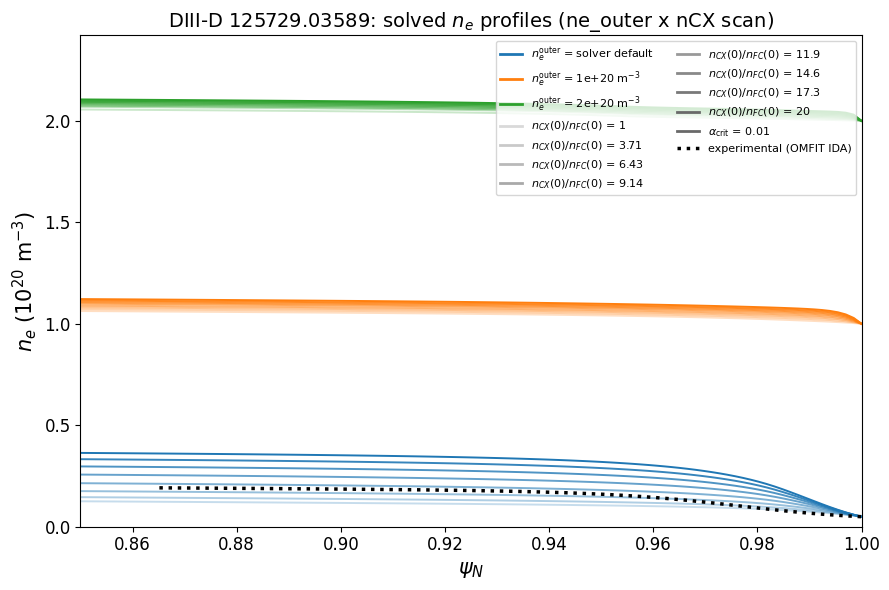

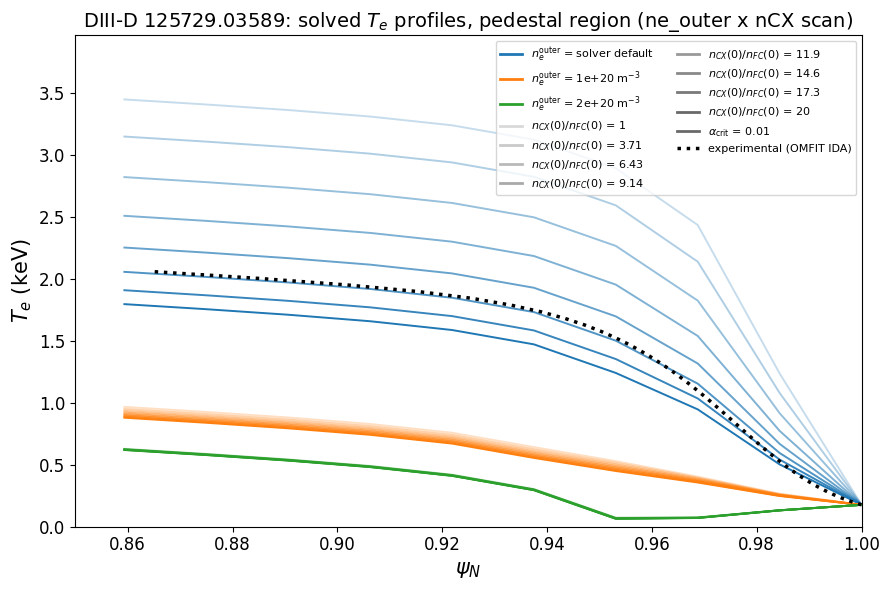

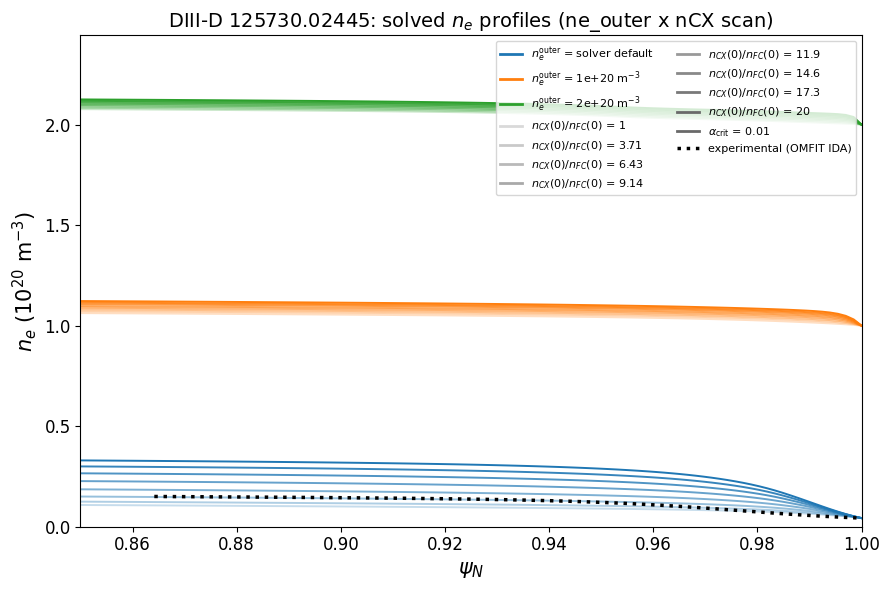

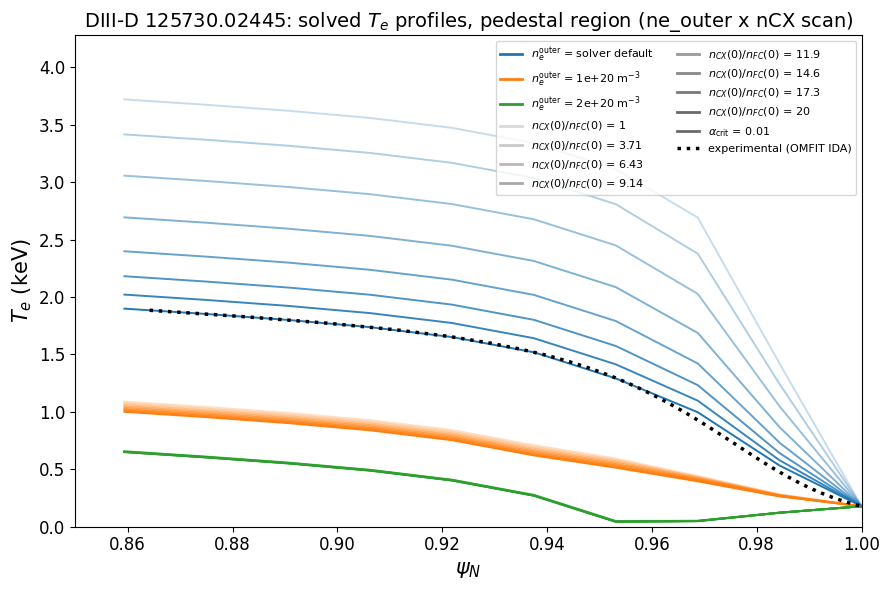

In [4]:
# --- DIII-D ne_outer x nCX scan: solved n_e and T_e profiles ---
# Reads DIIIDSnyder_freeparam_loop_nCXneouter/{EQUIL}/neouter{j}_fp{i}/ (out_dict.npy on
# success, failed.npy on failure; a run dir with neither is still in flight and is skipped).
# j indexes ne_x0s (the outer n_e boundary condition), i the free-parameter combo, both
# in the order scan_SCfp_ESCAPE.py generated them.
# n_e and T_e go on separate figures, with every parameter combination overplotted:
# colour = ne_outer, transparency = ncx_x0_ratio (opaque = large), linestyle = alpha_crit.

import re
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from matplotlib.lines import Line2D

# ------------------------------------------------------------------ user input
NEOUTER_SCAN_DIR = Path('DIIIDSnyder_freeparam_loop_nCXneouter')
# Equilibria to plot: None uses every one found in the scan directory, or give a
# tag ('125729.03589') / list of tags. Each equilibrium gets its own pair of figures.
NEOUTER_EQUILS = None
# alpha_crit families to draw: a value (0.01), a list ([0.01, 10]), or None for all.
NEOUTER_ALPHA_CRITS = 0.01
PSI_LO_NEOUTER = globals().get('PSI_LO', 0.85)   # pedestal window for both plots
# -----------------------------------------------------------------------------

# Same grids as scan_SCfp_ESCAPE.py, so neouter{j}_fp{i} maps back to its parameters.
NE_X0S_SCAN = [None, 1e20, 2e20]   # m^-3, outer BC on n_e (None = solver default)

NE_OUTER_COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
NEOUTER_LINESTYLES = ['-', '--', ':', '-.']


def load_neouter_runs(scan_dir, equil):
    """All finished ne_outer-scan runs for one equilibrium.

    Returns (runs, failed, pending); each run carries its free parameters, the
    ne_outer value its directory index encodes, and the solved/input profiles.
    """
    equil_dir = Path(scan_dir) / equil
    if not equil_dir.is_dir():
        raise FileNotFoundError(f'no such equilibrium directory: {equil_dir}')

    runs, failed, pending = [], [], []
    for run_dir in sorted(equil_dir.glob('neouter*_fp*'),
                          key=lambda p: tuple(int(v) for v in
                                              re.match(r'neouter(\d+)_fp(\d+)$', p.name).groups())):
        j = int(re.match(r'neouter(\d+)_fp(\d+)$', run_dir.name).group(1))
        out_fp = run_dir / 'out_dict.npy'
        if not out_fp.exists():
            (failed if (run_dir / 'failed.npy').exists() else pending).append(run_dir.name)
            continue
        d = np.load(out_fp, allow_pickle=True).item()
        runs.append({
            'ne_outer':     NE_X0S_SCAN[j],
            'alpha_crit':   float(d['free_params']['alpha_crit']),
            'ncx_x0_ratio': float(d['free_params']['ncx_x0_ratio']),
            'sol':          d['profiles_solved'],
            'profiles':     d['profiles'],
        })
    return runs, failed, pending


def _ne_outer_label(v):
    return 'solver default' if v is None else rf'{v:.3g} m$^{{-3}}$'


if NEOUTER_EQUILS is None:
    equils = [p.name for p in sorted(NEOUTER_SCAN_DIR.iterdir()) if p.is_dir()]
else:
    equils = list(np.atleast_1d(NEOUTER_EQUILS))

for equil in equils:
    runs, failed, pending = load_neouter_runs(NEOUTER_SCAN_DIR, equil)
    print(f'[nCXneouter] {equil}: successful {len(runs)}, '
          f'failed {len(failed)} ({", ".join(failed) or "-"}), '
          f'pending {len(pending)} ({", ".join(pending) or "-"})')
    if not runs:
        print('  no successful runs, skipping')
        continue

    alpha_vals = sorted({r['alpha_crit'] for r in runs})
    if NEOUTER_ALPHA_CRITS is not None:
        wanted = np.atleast_1d(np.asarray(NEOUTER_ALPHA_CRITS, dtype=float))
        alpha_vals = [a for a in alpha_vals if np.isclose(a, wanted).any()]
        runs = [r for r in runs if np.isclose(r['alpha_crit'], alpha_vals).any()]
        if not runs:
            print('  nothing left after the alpha_crit selection, skipping')
            continue
        print(f'  plotting alpha_crit = {", ".join(f"{a:g}" for a in alpha_vals)}')

    # colour per ne_outer, transparency per nCX ratio, linestyle per alpha_crit
    ne_outer_vals = [v for v in NE_X0S_SCAN if any(r['ne_outer'] == v for r in runs)]
    ne_color = {v: NE_OUTER_COLORS[k % len(NE_OUTER_COLORS)]
                for k, v in enumerate(ne_outer_vals)}
    ac_ls = {a: NEOUTER_LINESTYLES[k % len(NEOUTER_LINESTYLES)]
             for k, a in enumerate(alpha_vals)}
    ncx_vals = sorted({r['ncx_x0_ratio'] for r in runs})
    ncx_lo, ncx_hi = min(ncx_vals), max(ncx_vals)

    # How far up the nCX/nFC ratio each outer-BC family actually converged: runs
    # above this either failed or have not finished, so the transparency ramp does
    # not reach the top of the scanned range everywhere.
    print('  largest converged n_CX(0)/n_FC(0) ratio per n_e^outer:')
    for v in ne_outer_vals:
        ratios = [r['ncx_x0_ratio'] for r in runs if r['ne_outer'] == v]
        label = 'solver default' if v is None else f'{v:.3g} m^-3'
        print(f'    n_e^outer = {label:>15}: max ratio = {max(ratios):6.3g} '
              f'({len(ratios)} runs)')

    def ncx_alpha(ncx, lo=0.25, hi=1.0):
        """Transparency ramp: smallest nCX ratio faintest, largest fully opaque."""
        if ncx_hi == ncx_lo:
            return hi
        return lo + (hi - lo) * (ncx - ncx_lo) / (ncx_hi - ncx_lo)

    # experimental (input) profiles: identical for every run of this equilibrium
    exp_prof = runs[0]['profiles']
    psi_ne_exp = np.asarray(exp_prof['psi_N_ne'], dtype=float)
    ne_exp = np.asarray(exp_prof['ne'], dtype=float)
    psi_Te_exp = np.asarray(exp_prof['psi_N_Te'], dtype=float)
    te_exp = np.asarray(exp_prof['Te'], dtype=float)   # keV
    ped_ne = psi_ne_exp >= PSI_LO_NEOUTER
    ped_Te = psi_Te_exp >= PSI_LO_NEOUTER

    for quantity in ('ne', 'Te'):
        if quantity == 'ne':
            psi_key, val_key, scale = 'psi_N_ne', 'y', 1e-20
            ylabel = r'$n_e$ ($10^{20}$ m$^{-3}$)'
            psi_exp, val_exp, ped_exp = psi_ne_exp, ne_exp * 1e-20, ped_ne
            title = f'DIII-D {equil}: solved $n_e$ profiles (ne_outer x nCX scan)'
        else:
            psi_key, val_key, scale = 'psi_N', 'T_e', 1e-3   # eV -> keV
            ylabel = r'$T_e$ (keV)'
            psi_exp, val_exp, ped_exp = psi_Te_exp, te_exp, ped_Te
            title = (f'DIII-D {equil}: solved $T_e$ profiles, pedestal region '
                     f'(ne_outer x nCX scan)')

        fig, ax = plt.subplots(figsize=(9, 6))
        ped_max = float(val_exp[ped_exp].max())
        for r in runs:
            psi = np.asarray(r['sol'][psi_key], dtype=float)
            val = np.asarray(r['sol'][val_key], dtype=float) * scale
            ped = psi >= PSI_LO_NEOUTER   # pedestal window only, so the core does
            if not ped.any():             # not set the y-range
                continue
            ax.plot(psi[ped], val[ped],
                    ls=ac_ls[r['alpha_crit']],
                    color=ne_color[r['ne_outer']],
                    alpha=ncx_alpha(r['ncx_x0_ratio']),
                    linewidth=1.4)
            ped_max = max(ped_max, float(val[ped].max()))

        ax.plot(psi_exp[ped_exp], val_exp[ped_exp], 'k:', linewidth=2.5, zorder=10)

        ax.set_xlabel(r'$\psi_N$', fontsize=15)
        ax.set_ylabel(ylabel, fontsize=15)
        ax.set_xlim(PSI_LO_NEOUTER, 1.0)
        ax.set_ylim(0, 1.15 * ped_max)
        ax.tick_params(axis='both', labelsize=12)
        ax.set_title(title, fontsize=14)

        handles = [Line2D([], [], color=ne_color[v], lw=2,
                          label=rf'$n_e^{{\rm outer}}$ = {_ne_outer_label(v)}')
                   for v in ne_outer_vals]
        handles += [Line2D([], [], color='dimgray', lw=2, alpha=ncx_alpha(v),
                           label=rf'$n_{{CX}}(0)/n_{{FC}}(0)$ = {v:.3g}')
                    for v in ncx_vals]
        handles += [Line2D([], [], color='dimgray', lw=2, ls=ac_ls[a],
                           label=rf'$\alpha_{{\rm crit}}$ = {a:g}') for a in alpha_vals]
        handles += [Line2D([], [], color='k', ls=':', lw=2.5,
                           label='experimental (OMFIT IDA)')]
        ax.legend(handles=handles, fontsize=8, loc='best', ncol=2)

        plt.tight_layout()
        # plt.show()

[nFCneouter] 125729.03589: successful 27, failed 2 (neouter0_fp8, neouter0_fp9), pending 1 (neouter2_fp9)
  plotting alpha_crit = 0.01
  largest converged n_FC(0) per n_e^outer:
    n_e^outer =  solver default: max n_FC(0) = 8.799e+16 m^-3 (8 runs)
    n_e^outer =      1e+20 m^-3: max n_FC(0) = 3.162e+17 m^-3 (10 runs)
    n_e^outer =      2e+20 m^-3: max n_FC(0) = 1.668e+17 m^-3 (9 runs)


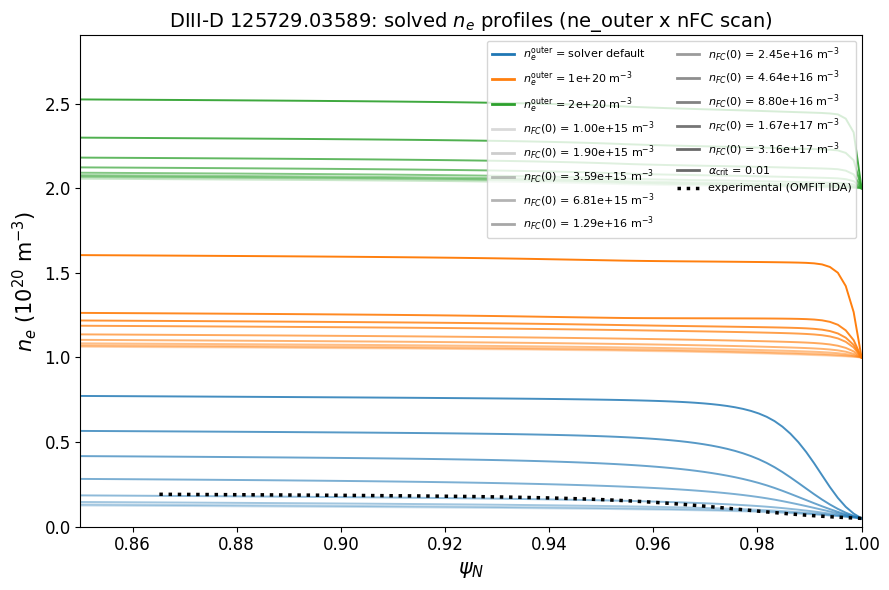

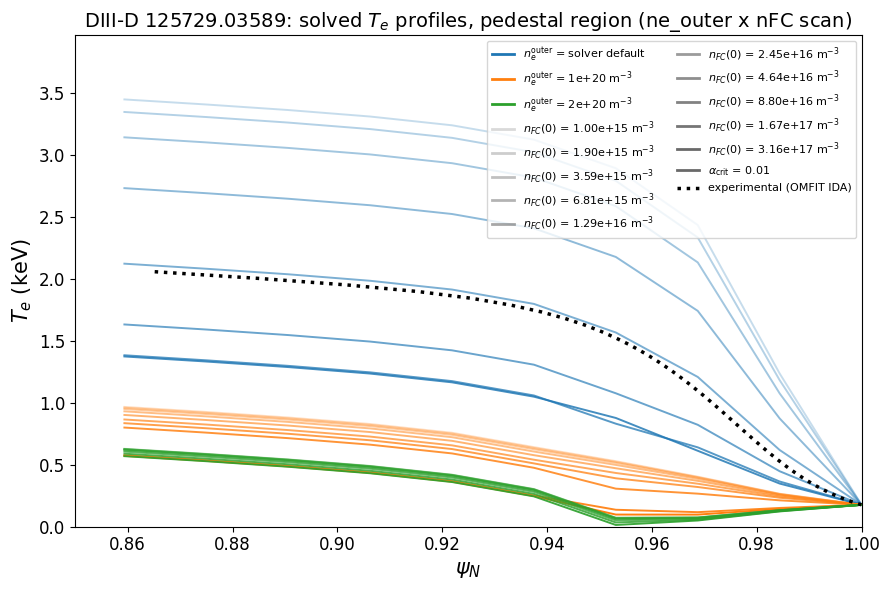

In [5]:
# --- DIII-D ne_outer x nFC scan: solved n_e and T_e profiles ---
# Same plots as the ne_outer x nCX cell above, for the nFC(0) scan.
# Reads DIIIDSnyder_freeparam_loop_nFCneouter/{EQUIL}/neouter{j}_fp{i}/ (out_dict.npy on
# success, failed.npy on failure; a run dir with neither is still in flight and is skipped).
# j indexes ne_x0s (the outer n_e boundary condition), i the free-parameter combo, both
# in the order scan_SCfp_ESCAPE.py generated them.
# n_e and T_e go on separate figures, with every parameter combination overplotted:
# colour = ne_outer, transparency = nFC_x0 (opaque = large, ramped in log space),
# linestyle = alpha_crit.

import re
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from matplotlib.lines import Line2D

# ------------------------------------------------------------------ user input
NEOUTER_SCAN_DIR = Path('DIIIDSnyder_freeparam_loop_nFCneouter')
# Equilibria to plot: None uses every one found in the scan directory, or give a
# tag ('125729.03589') / list of tags. Each equilibrium gets its own pair of figures.
NEOUTER_EQUILS = None
# alpha_crit families to draw: a value (0.01), a list ([0.01, 10]), or None for all.
NEOUTER_ALPHA_CRITS = 0.01
PSI_LO_NEOUTER = globals().get('PSI_LO', 0.85)   # pedestal window for both plots
# -----------------------------------------------------------------------------

# Same grids as scan_SCfp_ESCAPE.py, so neouter{j}_fp{i} maps back to its parameters.
NE_X0S_SCAN = [None, 1e20, 2e20]   # m^-3, outer BC on n_e (None = solver default)

NE_OUTER_COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
NEOUTER_LINESTYLES = ['-', '--', ':', '-.']


def load_neouter_nfc_runs(scan_dir, equil):
    """All finished ne_outer x nFC-scan runs for one equilibrium.

    Returns (runs, failed, pending); each run carries its free parameters, the
    ne_outer value its directory index encodes, and the solved/input profiles.
    """
    equil_dir = Path(scan_dir) / equil
    if not equil_dir.is_dir():
        raise FileNotFoundError(f'no such equilibrium directory: {equil_dir}')

    runs, failed, pending = [], [], []
    for run_dir in sorted(equil_dir.glob('neouter*_fp*'),
                          key=lambda p: tuple(int(v) for v in
                                              re.match(r'neouter(\d+)_fp(\d+)$', p.name).groups())):
        j = int(re.match(r'neouter(\d+)_fp(\d+)$', run_dir.name).group(1))
        out_fp = run_dir / 'out_dict.npy'
        if not out_fp.exists():
            (failed if (run_dir / 'failed.npy').exists() else pending).append(run_dir.name)
            continue
        d = np.load(out_fp, allow_pickle=True).item()
        runs.append({
            'ne_outer':     NE_X0S_SCAN[j],
            'alpha_crit':   float(d['free_params']['alpha_crit']),
            'nFC_x0':       float(d['free_params']['nFC_x0']),
            'sol':          d['profiles_solved'],
            'profiles':     d['profiles'],
        })
    return runs, failed, pending


def _ne_outer_label(v):
    return 'solver default' if v is None else rf'{v:.3g} m$^{{-3}}$'


if NEOUTER_EQUILS is None:
    equils = [p.name for p in sorted(NEOUTER_SCAN_DIR.iterdir()) if p.is_dir()]
else:
    equils = list(np.atleast_1d(NEOUTER_EQUILS))

for equil in equils:
    runs, failed, pending = load_neouter_nfc_runs(NEOUTER_SCAN_DIR, equil)
    print(f'[nFCneouter] {equil}: successful {len(runs)}, '
          f'failed {len(failed)} ({", ".join(failed) or "-"}), '
          f'pending {len(pending)} ({", ".join(pending) or "-"})')
    if not runs:
        print('  no successful runs, skipping')
        continue

    alpha_vals = sorted({r['alpha_crit'] for r in runs})
    if NEOUTER_ALPHA_CRITS is not None:
        wanted = np.atleast_1d(np.asarray(NEOUTER_ALPHA_CRITS, dtype=float))
        alpha_vals = [a for a in alpha_vals if np.isclose(a, wanted).any()]
        runs = [r for r in runs if np.isclose(r['alpha_crit'], alpha_vals).any()]
        if not runs:
            print('  nothing left after the alpha_crit selection, skipping')
            continue
        print(f'  plotting alpha_crit = {", ".join(f"{a:g}" for a in alpha_vals)}')

    # colour per ne_outer, transparency per nFC(0), linestyle per alpha_crit
    ne_outer_vals = [v for v in NE_X0S_SCAN if any(r['ne_outer'] == v for r in runs)]
    ne_color = {v: NE_OUTER_COLORS[k % len(NE_OUTER_COLORS)]
                for k, v in enumerate(ne_outer_vals)}
    ac_ls = {a: NEOUTER_LINESTYLES[k % len(NEOUTER_LINESTYLES)]
             for k, a in enumerate(alpha_vals)}
    nfc_vals = sorted({r['nFC_x0'] for r in runs})
    nfc_lo, nfc_hi = np.log10(min(nfc_vals)), np.log10(max(nfc_vals))

    # How far up nFC(0) each outer-BC family actually converged: runs above this
    # either failed or have not finished, so the transparency ramp does not reach
    # the top of the scanned range everywhere.
    print('  largest converged n_FC(0) per n_e^outer:')
    for v in ne_outer_vals:
        vals = [r['nFC_x0'] for r in runs if r['ne_outer'] == v]
        label = 'solver default' if v is None else f'{v:.3g} m^-3'
        print(f'    n_e^outer = {label:>15}: max n_FC(0) = {max(vals):9.3e} m^-3 '
              f'({len(vals)} runs)')

    def nfc_alpha(nfc, lo=0.25, hi=1.0):
        """Transparency ramp in log10(nFC): smallest faintest, largest opaque."""
        if nfc_hi == nfc_lo:
            return hi
        return lo + (hi - lo) * (np.log10(nfc) - nfc_lo) / (nfc_hi - nfc_lo)

    # experimental (input) profiles: identical for every run of this equilibrium
    exp_prof = runs[0]['profiles']
    psi_ne_exp = np.asarray(exp_prof['psi_N_ne'], dtype=float)
    ne_exp = np.asarray(exp_prof['ne'], dtype=float)
    psi_Te_exp = np.asarray(exp_prof['psi_N_Te'], dtype=float)
    te_exp = np.asarray(exp_prof['Te'], dtype=float)   # keV
    ped_ne = psi_ne_exp >= PSI_LO_NEOUTER
    ped_Te = psi_Te_exp >= PSI_LO_NEOUTER

    for quantity in ('ne', 'Te'):
        if quantity == 'ne':
            psi_key, val_key, scale = 'psi_N_ne', 'y', 1e-20
            ylabel = r'$n_e$ ($10^{20}$ m$^{-3}$)'
            psi_exp, val_exp, ped_exp = psi_ne_exp, ne_exp * 1e-20, ped_ne
            title = f'DIII-D {equil}: solved $n_e$ profiles (ne_outer x nFC scan)'
        else:
            psi_key, val_key, scale = 'psi_N', 'T_e', 1e-3   # eV -> keV
            ylabel = r'$T_e$ (keV)'
            psi_exp, val_exp, ped_exp = psi_Te_exp, te_exp, ped_Te
            title = (f'DIII-D {equil}: solved $T_e$ profiles, pedestal region '
                     f'(ne_outer x nFC scan)')

        fig, ax = plt.subplots(figsize=(9, 6))
        ped_max = float(val_exp[ped_exp].max())
        for r in runs:
            psi = np.asarray(r['sol'][psi_key], dtype=float)
            val = np.asarray(r['sol'][val_key], dtype=float) * scale
            ped = psi >= PSI_LO_NEOUTER   # pedestal window only, so the core does
            if not ped.any():             # not set the y-range
                continue
            ax.plot(psi[ped], val[ped],
                    ls=ac_ls[r['alpha_crit']],
                    color=ne_color[r['ne_outer']],
                    alpha=nfc_alpha(r['nFC_x0']),
                    linewidth=1.4)
            ped_max = max(ped_max, float(val[ped].max()))

        ax.plot(psi_exp[ped_exp], val_exp[ped_exp], 'k:', linewidth=2.5, zorder=10)

        ax.set_xlabel(r'$\psi_N$', fontsize=15)
        ax.set_ylabel(ylabel, fontsize=15)
        ax.set_xlim(PSI_LO_NEOUTER, 1.0)
        ax.set_ylim(0, 1.15 * ped_max)
        ax.tick_params(axis='both', labelsize=12)
        ax.set_title(title, fontsize=14)

        handles = [Line2D([], [], color=ne_color[v], lw=2,
                          label=rf'$n_e^{{\rm outer}}$ = {_ne_outer_label(v)}')
                   for v in ne_outer_vals]
        handles += [Line2D([], [], color='dimgray', lw=2, alpha=nfc_alpha(v),
                           label=rf'$n_{{FC}}(0)$ = {v:.2e} m$^{{-3}}$')
                    for v in nfc_vals]
        handles += [Line2D([], [], color='dimgray', lw=2, ls=ac_ls[a],
                           label=rf'$\alpha_{{\rm crit}}$ = {a:g}') for a in alpha_vals]
        handles += [Line2D([], [], color='k', ls=':', lw=2.5,
                           label='experimental (OMFIT IDA)')]
        ax.legend(handles=handles, fontsize=8, loc='best', ncol=2)

        plt.tight_layout()
        # plt.show()

# D_ETG and C_KBM scans


[De_chie_etg] successful 94, failed 0 (-), pending 1 (131996.03020/neouter0_fp4)
  16 equilibria, $D_{e}\chi_{e}^{\mathrm{ETG}}$ = 0.1, 0.55, 1, alpha_crit = 0.01, 10


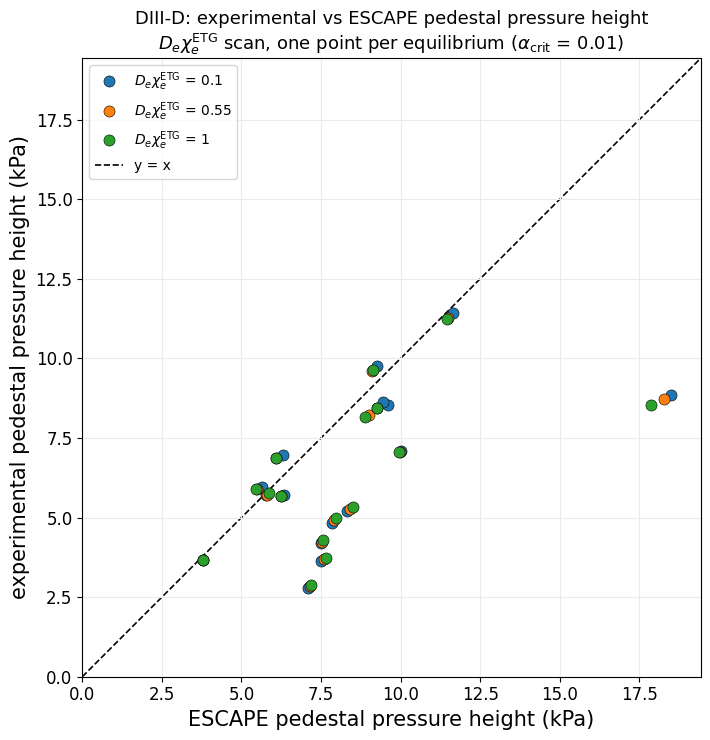

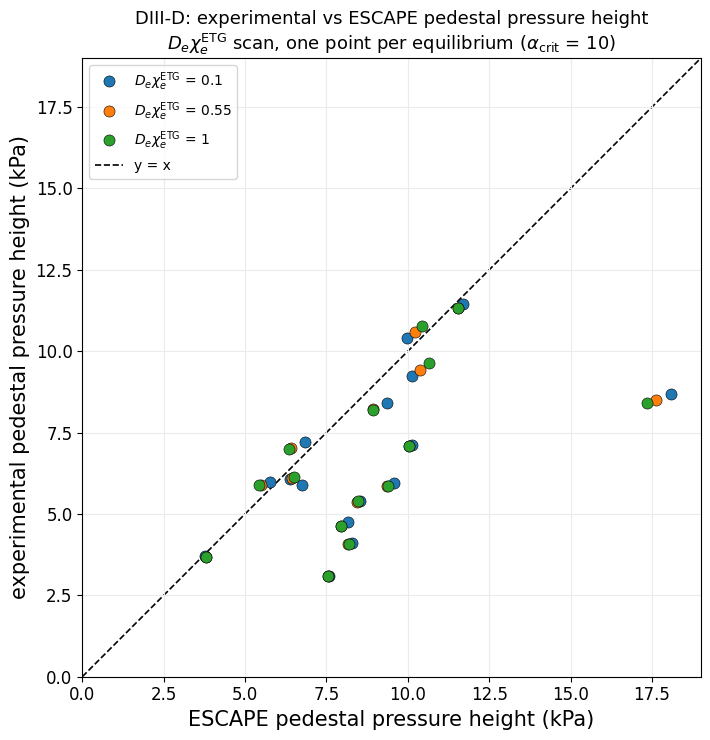

[C_KBM] successful 94, failed 0 (-), pending 1 (132020.01965/neouter0_fp1)
  32 equilibria, $C_{\mathrm{KBM}}$ = 0.1, 0.55, 1, alpha_crit = 0.01


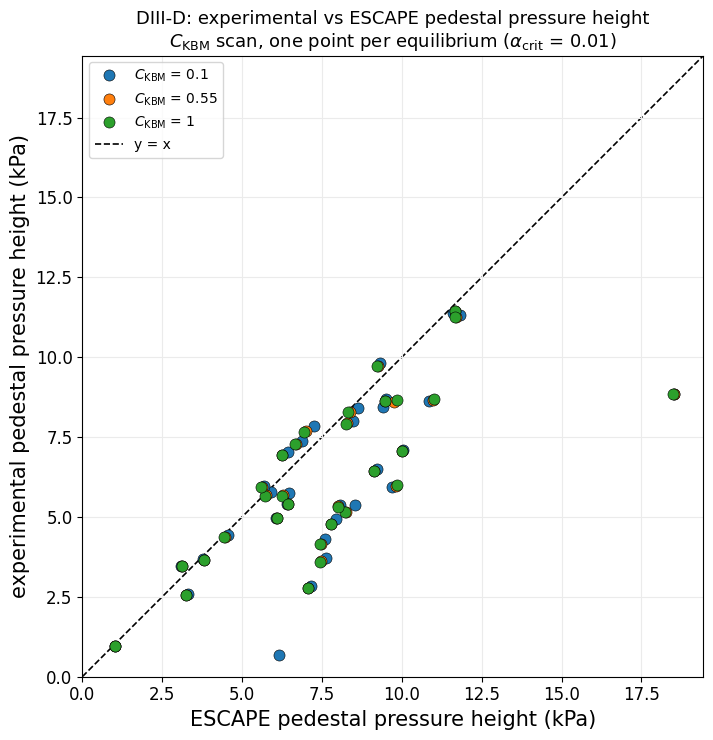

In [6]:
# --- D_ETG and C_KBM scans: ESCAPE vs experimental pedestal pressure height ---
# Reads DIIIDSnyder_freeparam_loop_{DETG,CKBM}/{EQUIL}/neouter{j}_fp{i}/ (out_dict.npy
# on success, failed.npy on failure; a run dir with neither is still in flight and is
# skipped). Both scans hold every other free parameter fixed and step one of
# De_chie_etg / C_KBM, over all the DIII-D equilibria.
# The pedestal pressures are the ones the scan already stored, exactly as in the
# nFC/nCX plots above: ESCAPE_ped_h (MPa -> kPa) and experimental_ped_h (Pa -> kPa),
# the latter being the input profile pressure at psi_N = 1 - ped_wid of that run.
# Each point is one equilibrium: x = the model's pedestal pressure height, y = the
# experimental one, both evaluated at the pedestal width that run predicted. One
# colour per scanned value; each alpha_crit family gets its own figure.

import re
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from matplotlib.lines import Line2D

# ------------------------------------------------------------------ user input
SCALAR_SCANS = {
    'De_chie_etg': dict(scan_dir=Path('DIIIDSnyder_freeparam_loop_DETG'),
                        label=r'$D_{e}\chi_{e}^{\mathrm{ETG}}$',
                        fmt=lambda v: f'{v:g}'),
    'C_KBM':       dict(scan_dir=Path('DIIIDSnyder_freeparam_loop_CKBM'),
                        label=r'$C_{\mathrm{KBM}}$',
                        fmt=lambda v: f'{v:g}'),
}
PARAM_COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
                'tab:purple', 'tab:brown']
# -----------------------------------------------------------------------------


def load_scalar_scan(scan_dir, param_key):
    """Every finished run of one scan, over all its equilibria.

    Returns (runs, failed, pending); pedestal heights are converted the same way
    as load_runs above (ESCAPE MPa -> kPa, experimental Pa -> kPa).
    """
    scan_dir = Path(scan_dir)
    runs, failed, pending = [], [], []
    for equil_dir in sorted(p for p in scan_dir.iterdir() if p.is_dir()):
        for run_dir in sorted(equil_dir.glob('neouter*_fp*'),
                              key=lambda p: tuple(int(v) for v in
                                                  re.match(r'neouter(\d+)_fp(\d+)$',
                                                           p.name).groups())):
            out_fp = run_dir / 'out_dict.npy'
            if not out_fp.exists():
                name = f'{equil_dir.name}/{run_dir.name}'
                (failed if (run_dir / 'failed.npy').exists()
                 else pending).append(name)
                continue
            d = np.load(out_fp, allow_pickle=True).item()
            runs.append({
                'equil':      equil_dir.name,
                'alpha_crit': float(d['free_params']['alpha_crit']),
                'param':      float(d['free_params'][param_key]),
                'ped_h':      float(d['ESCAPE_ped_h']) * 1e3,        # MPa -> kPa
                'ped_wid':    float(d['ESCAPE_ped_wid']),
                'p_exp':      float(d['experimental_ped_h']) / 1e3,  # Pa  -> kPa
            })
    return runs, failed, pending


for param_key, spec in SCALAR_SCANS.items():
    if not spec['scan_dir'].is_dir():
        print(f'[{param_key}] {spec["scan_dir"]} not found, skipping')
        continue

    runs, failed, pending = load_scalar_scan(spec['scan_dir'], param_key)
    print(f'[{param_key}] successful {len(runs)}, '
          f'failed {len(failed)} ({", ".join(failed) or "-"}), '
          f'pending {len(pending)} ({", ".join(pending) or "-"})')
    if not runs:
        print('  no successful runs yet, nothing to plot')
        continue

    equils = sorted({r['equil'] for r in runs})
    param_vals = sorted({r['param'] for r in runs})
    alpha_vals = sorted({r['alpha_crit'] for r in runs})
    param_color = {v: PARAM_COLORS[k % len(PARAM_COLORS)]
                   for k, v in enumerate(param_vals)}
    x_of = {e: k for k, e in enumerate(equils)}
    print(f'  {len(equils)} equilibria, {spec["label"]} = '
          f'{", ".join(spec["fmt"](v) for v in param_vals)}, '
          f'alpha_crit = {", ".join(f"{a:g}" for a in alpha_vals)}')

    for a in alpha_vals:
        fig, ax = plt.subplots(figsize=(8, 7.5))
        for v in param_vals:
            g = [r for r in runs
                 if np.isclose(r['alpha_crit'], a) and np.isclose(r['param'], v)]
            if not g:
                continue
            ax.plot([r['ped_h'] for r in g], [r['p_exp'] for r in g], 'o',
                    color=param_color[v], markersize=8, linestyle='none',
                    markeredgecolor='black', markeredgewidth=0.4,
                    label=rf'{spec["label"]} = {spec["fmt"](v)}')

        # y = x: the model reproduces the experimental pedestal pressure exactly
        sel = [r for r in runs if np.isclose(r['alpha_crit'], a)]
        lim_hi = 1.05 * max(max(r['ped_h'] for r in sel), max(r['p_exp'] for r in sel))
        ax.plot([0, lim_hi], [0, lim_hi], 'k--', linewidth=1.2, zorder=0,
                label='y = x')

        ax.set_xlim(0, lim_hi)
        ax.set_ylim(0, lim_hi)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('ESCAPE pedestal pressure height (kPa)', fontsize=15)
        ax.set_ylabel('experimental pedestal pressure height (kPa)', fontsize=15)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(color='0.92', linewidth=0.8)
        ax.set_axisbelow(True)
        ax.legend(fontsize=10, loc='best')
        ax.set_title(f'DIII-D: experimental vs ESCAPE pedestal pressure height\n'
                     f'{spec["label"]} scan, one point per equilibrium '
                     rf'($\alpha_{{\mathrm{{crit}}}}$ = {a:g})', fontsize=13)
        plt.tight_layout()
        plt.show()